# Section 5.5

## Example 5.5.3

Let's observe the convergence of the formulas in {numref}`Example {number} <example-fd-converge-FD11>` and {numref}`Example {number} <example-fd-converge-FD12>`, applied to the function $\sin(e^{x+1})$ at $x=0$.

In [1]:
f(x) = sin(exp(x + 1))
exact_value = exp(1) * cos(exp(1))

-2.478349732955235

We'll compute the formulas in parallel for a sequence of $h$ values.

In [2]:
using PrettyTables

h = [5 / 10^n for n in 1:6]
FD = zeros(length(h), 2)
for (k, h) in enumerate(h)
    FD[k, 1] = (f(h) - f(0)) / h
    FD[k, 2] = (f(h) - f(-h)) / 2h
end
pretty_table([h FD]; column_labels=["h", "FD1", "FD2"], backend=:html)

h,FD1,FD2
0.5,-2.76858,-1.97047
0.05,-2.6128,-2.47552
0.005,-2.49211,-2.47832
0.0005,-2.47973,-2.47835
5.0e-5,-2.47849,-2.47835
5.0e-6,-2.47836,-2.47835


All that's easy to see from this table is that FD2 appears to converge to the same result as FD1, but more rapidly. A table of errors is more informative.

In [3]:
error_FD = @. exact_value - FD
pretty_table([h error_FD]; 
    column_labels=["h", "error in FD1", "error in FD2"], backend=:html)

h,error in FD1,error in FD2
0.5,0.290226,-0.507878
0.05,0.134446,-0.00282948
0.005,0.0137555,-2.80378e-5
0.0005,0.00137813,-2.80353e-7
5.0e-5,0.000137838,-2.80297e-9
5.0e-6,1.37841e-5,1.53291e-11


In each row, $h$ is decreased by a factor of 10, so that the error is reduced by a factor of 10 in the first-order method and 100 in the second-order method.

A graphical comparison can be useful as well. On a log-log scale, the error should (as $h\to 0$) be a straight line whose slope is the order of accuracy. However, it's conventional in convergence plots to show $h$ _decreasing_ from left to right, which negates the slopes.

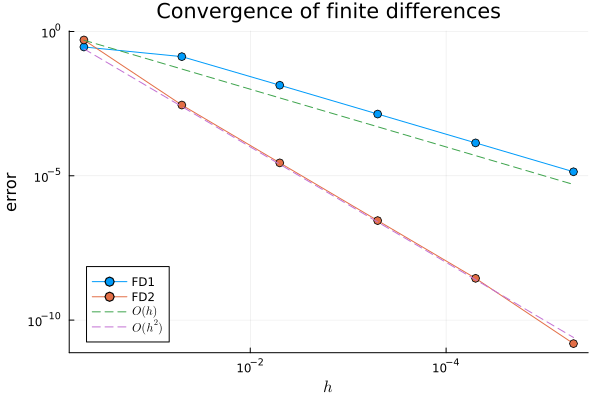

In [5]:
using Plots, LaTeXStrings

plot(h, abs.(error_FD); 
    m=:o,  label=["FD1" "FD2"], leg=:bottomleft,
    xflip=true,  xaxis=(:log10, L"h"),  yaxis=(:log10, "error"),
    title="Convergence of finite differences")

# Add lines for perfect 1st and 2nd order.
plot!(h, [h h .^ 2], l=:dash, label=[L"O(h)" L"O(h^2)"])

## Example 5.5.4

Let $f(x)=e^{-1.3x}$. We apply finite-difference formulas of first, second, and fourth order to estimate $f'(0)=-1.3$.

In [7]:
using LinearAlgebra, PrettyTables

f(x) = exp(-1.3x)
exact = -1.3

h = [1 / 10^n for n in 1:12]
FD = zeros(length(h), 3)
for (k, h) in enumerate(h)
    nodes = h * (-2:2)
    vals = @. f(nodes)
    FD[k, 1] = dot([0 0 -1 1 0] / h, vals)
    FD[k, 2] = dot([0 -1 / 2 0 1 / 2 0] / h, vals)
    FD[k, 3] = dot([1 / 12 -2 / 3 0 2 / 3 -1 / 12] / h, vals)
end
pretty_table([h FD]; column_labels=["h", "FD1", "FD2", "FD4"], backend=:html)

h,FD1,FD2,FD4
0.1,-1.21905,-1.30366,-1.29999
0.01,-1.29159,-1.30004,-1.3
0.001,-1.29916,-1.3,-1.3
0.0001,-1.29992,-1.3,-1.3
1.0e-5,-1.29999,-1.3,-1.3
1.0e-6,-1.3,-1.3,-1.3
1.0e-7,-1.3,-1.3,-1.3
1.0e-8,-1.3,-1.3,-1.3
1.0e-9,-1.3,-1.3,-1.3
1.0e-10,-1.3,-1.3,-1.3


They all seem to be converging to $-1.3$. The convergence plot reveals some interesting structure to the errors, though.

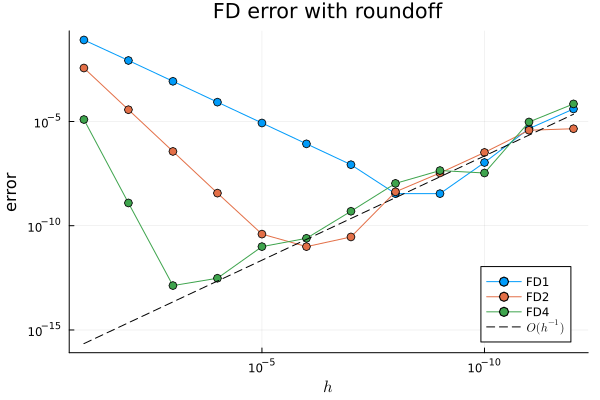

In [8]:
using Plots, LaTeXStrings

err = @. abs(FD - exact)

plot(h, err;
    m=:o, label=["FD1" "FD2" "FD4"],  legend=:bottomright,
    xaxis=(:log10, L"h"),  xflip=true,  yaxis=(:log10, "error"),
    title="FD error with roundoff")

# Add line for perfect 1st order.
plot!(h, 0.1 * eps() ./ h, l=:dash, color=:black, label=L"O(h^{-1})")

Again the graph is made so that $h$ decreases from left to right. The errors are dominated at first by truncation error, which decreases most rapidly for the fourth-order formula. However, increasing roundoff error eventually equals and then dominates the truncation error as $h$ continues to decrease. As the order of accuracy increases, the crossover point moves to the left (greater efficiency) and down (greater accuracy).